# **Introducción a TensorFlow**

Este cuaderno es una introducción a Tensorflow, utilizando ejemplos para realizar diversas operaciones. Se recomienda **encarecidamente** hacer un uso extensivo de la API de TensorFlow en <a href="https://www.tensorflow.org/api_docs/python/tf">https://www.tensorflow.org/api_docs/python/tf</a>, así como de los tutoriales accesibles desde <a href="https://www.tensorflow.org/tutorials?hl=es-419">https://www.tensorflow.org/tutorials?hl=es-419</a>.

# **Primeros pasos: Creación de tensores**

Normalmente, la biblioteca Tensorflow se importa desde Python de la siguiente forma:

In [ ]:
import tensorflow as tf

Un **tensor** es la representación de Tensorflow para un array multidimensional.

Hay dos tipos de tensores:

- Constantes (lo habitual): Tipo **tf.constant**.
- Modificables: Tipo **tf.Variable**. Sólo se pueden modificar de forma integral, y haciendo uso de operaciones internas de la biblioteca.

In [ ]:
# Creación de tensor constante desde listas Python
a= tf.constant([1, 2, 3], shape=(3,), dtype=tf.float32)

try:
  # Esta línea produce un error. a es constante
  a[0]= 3
except:
  pass

print('Mi primer tensor constante: ', a)


# Creación de tensor variable desde listas Python
b= tf.Variable([1, 2, 3], shape=(3,), dtype=tf.float32)
print('Mi primer tensor variable: ', b)

try:
  # Esta línea produce un error. b se debe modificar con funciones de tf
  b[0]= 3 # Esto sígue sin poderse hacer
except:
  pass

# Asignación de valores de un tensor de forma integral, haciendo uso de
#  funciones de tf
b.assign([3, 2, 1]) # Se asigna el tensor al completo
print('Mi primer tensor variablemodificado: ', b)



Mi primer tensor constante:  tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32)
Mi primer tensor variable:  <tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>
Mi primer tensor variablemodificado:  <tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([3., 2., 1.], dtype=float32)>


Hay una gran integración entre Tensorflow y NumPy. Se puede pasar un array de una biblioteca a otra sin problemas.

In [ ]:
import numpy as np

# Creación de tensor desde NumPy
c_n= np.array([1, 2, 3], dtype=np.float32)
print('Array NumPy: ', c_n)

c_t= tf.convert_to_tensor(c_n)
print('Tensor desde Numpy: ', c_t)


# Creación de ndarray desde Tensor
c_n2= c_t.numpy()
c_t= tf.convert_to_tensor(c_n)
print('NDArray desde tensor: ', c_n2)




Array NumPy:  [1. 2. 3.]
Tensor desde Numpy:  tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32)
NDArray desde tensor:  [1. 2. 3.]


En Tensorflow tenemos prácticamente las mismas funciones para crear tensores que teníamos en NumPy. Algunos ejemplos:

In [ ]:
# Creación de tensor de ceros de 3 filas y 2 columnas
z= tf.zeros(shape=(3,2))
print('Tensor 3x2 de ceros:\n{}'.format(z))

# Creación de tensor de unos de 2 componentes
o= tf.ones(shape=(2))
print('\nTensor de 2 unos:\n{}'.format(o))

# Creación de matriz identidad de 3x3
e= tf.eye(num_rows=3)
print('\nMatriz identidad:\n{}'.format(e))



Tensor 3x2 de ceros:
[[0. 0.]
 [0. 0.]
 [0. 0.]]
Tensor de 2 unos:
[1. 1.]
Matriz identidad:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


El **casting** o transformación de tipos sí difiere un poco con NumPy, aunque es sencillo igualmente:

In [ ]:
# Cambio de tipo: casting
print('Tensor original:\n', e)
e_i= tf.cast(e, tf.int64)
print('\nTensor Eye tras casting a entero: ', e_i)



También tenemos funciones para cambiar de forma a un tensor, como **reshape** de NumPy o **squeeze**. Por ejemplo:

In [ ]:
# Cambio de forma de un tensor
print('Tensor original:\n{}'.format(e))
e_0= tf.reshape(e, shape=(1, 9))
print('\nEjemplo de reshape a (1,9): \n{}'.format(e_0))

# Eliminación de dimensiones sin usar
e_0_sq= tf.squeeze(e_0)
print('\nEjemplo de squeeze sobre el tensor anterior: \n{}'.format(e_0_sq))




Tensor original:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Ejemplo de reshape a (1,9):  tf.Tensor([[1. 0. 0. 0. 1. 0. 0. 0. 1.]], shape=(1, 9), dtype=float32)
Ejemplo de squeeze sobre el tensor anterior:  tf.Tensor([1. 0. 0. 0. 1. 0. 0. 0. 1.], shape=(9,), dtype=float32)


# **Operaciones con tensores**

Disponemos de las mismas operaciones con tensores que con tipos **ndarray** en NumPy. Los nombres suelen mantenerse, aunque algunos pueden sufrir cambios sutiles. Por ejemplo:

In [ ]:

# Generación de matrices aleatorias de 2x3
a= tf.random.uniform(shape=(2, 3))
b= tf.random.normal(shape=(2, 3)) # Distribución N(0,1)
print('La matriz "a" vale:\n', a)
print('\nLa matriz "b" vale:\n', b)

# Suma componente a componente de a y b
print('\nLa suma de ambas es:\n', tf.add(a, b))
print('\nLa suma de ambas es:\n', a+b) # sobrecarga del operador +

print('\nMultiplicación de a*b (componente a componente):\n', tf.multiply(a, b))

print('\nMedia de las componentes de a:\n', tf.reduce_mean(a))

print('\nMedia de las COLUMNAS de a:\n', tf.reduce_mean(a, axis=1))

print('\nTraspuesta de b:\n', tf.transpose(b))

print('\nMultiplicación matricial de a*b^t:\n', tf.linalg.matmul(a, tf.transpose(b)))

# Sobrecarga de @ (como en NumPy)
print('\nMultiplicación matricial de a*b^t:\n', a @ tf.transpose(b))


La matriz "a" vale:
 tf.Tensor(
[[0.7119565  0.24616754 0.9778886 ]
 [0.94295514 0.44409883 0.75884616]], shape=(2, 3), dtype=float32)

La matriz "b" vale:
 tf.Tensor(
[[-1.8678523  -0.34818527  0.64855015]
 [-2.7525876   0.9937949   0.22834764]], shape=(2, 3), dtype=float32)

La suma de ambas es:
 tf.Tensor(
[[-1.1558958  -0.10201773  1.6264387 ]
 [-1.8096324   1.4378937   0.9871938 ]], shape=(2, 3), dtype=float32)

La suma de ambas es:
 tf.Tensor(
[[-1.1558958  -0.10201773  1.6264387 ]
 [-1.8096324   1.4378937   0.9871938 ]], shape=(2, 3), dtype=float32)

Multiplicación de a*b (componente a componente):
 tf.Tensor(
[[-1.3298296  -0.08571191  0.6342098 ]
 [-2.5955665   0.44134316  0.17328073]], shape=(2, 3), dtype=float32)

Media de las componentes de a:
 tf.Tensor(0.68031883, shape=(), dtype=float32)

Media de las COLUMNAS de a:
 tf.Tensor([0.6453375 0.7153001], shape=(2,), dtype=float32)

Traspuesta de b:
 tf.Tensor(
[[-1.8678523  -2.7525876 ]
 [-0.34818527  0.9937949 ]
 [ 0.6485501

# **Indexación de tensores**

Las formas de indexación de NumPy se suelen respetar en su mayoría en Tensorflow. Gracias a esto, podemos migrar fácilmente de una biblioteca a otra.

Algunos ejemplos:

In [ ]:
# Creación de tensor
a= tf.random.normal(shape=(20,))
print('Matriz de tamaño {}:\n'.format(a.shape), a)


# Indexación booleana
b= (a>=0) # Creación de array bool
b_int= tf.cast(b, tf.int64) # Transformación a numérico (para poder aplicar reduce_sum)
print('\nElementos no negativos: {}. Hay un total de {}'.format(b, tf.reduce_sum(b_int)))

c= a[b] # Indexación booleana
print('\nElementos no negativos con indexación: ', c.shape)

# Indexación con :
d= a[1:10]
print('\nLos elementos del segundo al décimo: ', d)


Matriz de tamaño (20,):
 tf.Tensor(
[-0.29117224 -2.516301   -0.8066311  -0.43950108 -0.81964314  0.38493815
 -1.3066559  -1.0204602   0.3689234   1.9491272   0.20601916  0.27310818
 -0.39221993  1.387847   -0.98305905  0.4604131  -0.331607    0.86389375
 -0.32483664  0.5533946 ], shape=(20,), dtype=float32)

Elementos no negativos: [False False False False False  True False False  True  True  True  True
 False  True False  True False  True False  True]. Hay un total de 9

Elementos no negativos con indexación:  (9,)

Los elementos del segundo al décimo:  tf.Tensor(
[-2.516301   -0.8066311  -0.43950108 -0.81964314  0.38493815 -1.3066559
 -1.0204602   0.3689234   1.9491272 ], shape=(9,), dtype=float32)


Lo mismo ocurre con tensores multidimensionales:

In [ ]:

# tensor multidimensional
a= tf.random.normal(shape=(20,2))
print('Tensor a:\n{}'.format(a))


# Indexación booleana
b= (a>=0) # Creación de array bool
b_int= tf.cast(b, tf.int64)
print('\n#Elementos no negativos: ', tf.reduce_sum(b_int))
c= a[b] # Indexación booleana
print('Elementos no negativos con indexación: ', c.shape)

# Indexación con :
d= a[1:10]
print('\nLos elementos del segundo al décimo: ', d)


# **Cambio de forma**

Tensorflow tiene también diversas opciones para cambiar la forma o combinar tensores, al igual que NumPy.

Algunos ejemplos:

In [26]:
# Tensor
a= tf.random.uniform(shape=(999, 1))
print('Tengo un tensor de forma {}'.format(a.shape))

##############################################
# Uso de squeeze
a= tf.squeeze( a )
print('Tras squeeze, la forma es: {}'.format(a.shape))


##############################################
# División con split
splits= tf.split(a, num_or_size_splits=3)
print('Lo he dividido en {} partes de formas {}'.format(len(splits), splits[0].shape))

print('Las 2 primeras componentes del último split son: {}'.format(splits[-1][:2]))


##############################################3
# Concatenación con concat
a= tf.random.uniform(shape=(2,))
b= tf.random.uniform(shape=(3,))
print('\n\nTengo dos tensores a y b de formas {}  y {}'.format(a.shape, b.shape))
print('a={}'.format(a))
print('b={}'.format(b))

c= tf.concat([a,b], axis=0)
print('\nTras hacer concat(a,b):', c)


##############################################3
# Apilación con stack
a= tf.random.uniform(shape=(3,))
b= tf.random.uniform(shape=(3,))
print('\n\nTengo dos tensores a y b de formas {} y {}'.format(a.shape, b.shape))
print('a={}'.format(a))
print('b={}'.format(b))

c= tf.stack([a,b], axis=0)
print('stack(a,b) en axis=0:', c)
d= tf.stack([a,b], axis=1)
print('stack(a,b) en axis=1:', d)


##############################################3
# Selección con gather
a= tf.convert_to_tensor([[0.1, 0.2],
                         [0.3, -0.4],
                         [0.5, -0.6],
                         [0.7, 0.8]])
print('\n\nTengo el tensor:\n{}'.format(a))

b= tf.gather_nd(a, indices = [2, 1])
print('Su elemento en [2,1] son: {}'.format(b))

c= tf.gather_nd(a, indices = [[2], [1]])
print('Sus filas [[2], [1]] son: \n{}'.format(c))

Tengo un tensor de forma (999, 1)
Tras squeeze, la forma es: (999,)
Lo he dividido en 3 partes de formas (333,)
Las 2 primeras componentes del último split son: [0.96464145 0.5109532 ]


Tengo dos tensores a y b de formas (2,)  y (3,)
a=[0.8317913  0.40351892]
b=[0.53925717 0.7701467  0.94953287]

Tras hacer concat(a,b): tf.Tensor([0.8317913  0.40351892 0.53925717 0.7701467  0.94953287], shape=(5,), dtype=float32)


Tengo dos tensores a y b de formas (3,) y (3,)
a=[0.45571458 0.04448295 0.4198916 ]
b=[0.504884   0.7666513  0.65007615]
stack(a,b) en axis=0: tf.Tensor(
[[0.45571458 0.04448295 0.4198916 ]
 [0.504884   0.7666513  0.65007615]], shape=(2, 3), dtype=float32)
stack(a,b) en axis=1: tf.Tensor(
[[0.45571458 0.504884  ]
 [0.04448295 0.7666513 ]
 [0.4198916  0.65007615]], shape=(3, 2), dtype=float32)


Tengo el tensor:
[[ 0.1  0.2]
 [ 0.3 -0.4]
 [ 0.5 -0.6]
 [ 0.7  0.8]]
Su elemento en [2,1] son: -0.6000000238418579
Sus filas [[2], [1]] son: 
[[ 0.5 -0.6]
 [ 0.3 -0.4]]


# **Primeros pasos con autograd**

Autograd, en Tensorflow, se encarga de realizar el cálculo automatizado de gradientes (derivadas en un punto). Para ello, utiliza el grafo de cómputo o secuencia de operaciones realizadas y calcula el gradiente sobre las mismas con respecto a una o varias variables dada.

Las operaciones a monitorizar deben guardarse de forma secuencial en una zona de memoria denominada **cinta**. Cuando deseemos calcular el gradiente, indicaremos cuál variable es la salida y cuál debe ser sobre la que calculamos la derivada.

Por ejemplo, supongamos una variable **X** y la operación $Y= f(X)= X^2$. Deseamos calcular $\partial{}{{f}\over{\partial{X}}}(X)$.

El siguiente código muestra cómo calcular la derivada de la función para el punto $X=3.0$:

In [29]:

# Generamos la variable (de tipo Variable) en el punto a evaluar
X= tf.Variable(3.0)

# Guardamos el grafo de cómputo en la cinta
with tf.GradientTape() as tape:
    Y= X**2

# Cálculo de la derivada de Y con respecto a X
derivada= tape.gradient(Y, X)

print('La derivada en x=', X.numpy(), 'es', derivada.numpy())
print("Su cálculo analítico es Y'= 2*X. Su valor es: ", 2*X.numpy())


La derivada en x= 3.0 es 6.0
Su cálculo analítico es Y'= 2*X. Su valor es:  6.0


## Veamos un ejemplo más elaborado.



Supongamos que tenemos una función **f(x)** de la que queremos calcular su mínimo. Para ello, haremos uso del método del descenso del gradiente y actualizaremos la variable de interés **x** como:

$x= x-\lambda\partial{}{{f}\over{x}}(x)$, con una tasa de aprendizaje fijada al valor $\lambda$ prefijado como hiperparámetro.

La función de la que queremos calcular el mínimo es la siguiente:

$f(x)= (x-1)^2 + 2$

De forma analítica, podemos calcular el mínimo de la función calculando $f'(x)$ e igualando el término al valor 0 y despejando el valor de x:

$f'(x)= 2(x-1)$

$2(x-1)= 0 \rightarrow x=1$

Sabemos que en $x=1$ hay un mínimo/máximo (en este caso es un mínimo).

Vamos a comprobar si el algoritmo del descenso del gradiente funciona en este caso integrando su funcionamiento con **autograd** en **Tensorflow**:


In [39]:
# Definimos la función a optimizar
def FuncionAOptimizar(X):
    return (X-1)**2 + 2

# Generamos un valor inicial x_0 entre 0 y 10
X0= tf.squeeze( tf.random.uniform(shape=(1,)) )*10

# Inicializamos nuestra variable con dicho valor
X= tf.Variable(X0)
print('Punto inicial X={}\n'.format(X.numpy()))

Num_itera= 10 # Número de iteraciones
lmbda= 0.3 # Tasa de aprendizaje/step size



# Iteramos un número máximo de Num_itera veces
for i in range(Num_itera):

    # Forward pass: Cálculo de Y=f(X)
    with tf.GradientTape() as tape:
        Y= FuncionAOptimizar(X)

    # Cálculo de derivadas (gradientes) de Y con respecto a X
    dYdX= tape.gradient(Y, X) # Coger gradientes

    print('En la iteración {} obtengo el gradiente {}'.format(i+1, dYdX))

    # Actualización del descenso del gradiente
    X= tf.Variable(X-lmbda*dYdX) # Regla del descenso del gradiente
    print('\ty actualizo el punto a X={}'.format(X.numpy()))

print('\nEl mínimo de la función está en aproximadamente X={}'.format(X.numpy()))

Punto inicial X=4.72254753112793

En la iteración 1 obtengo el gradiente 7.445095062255859
	y actualizo el punto a X=2.4890189170837402
En la iteración 2 obtengo el gradiente 2.9780378341674805
	y actualizo el punto a X=1.5956075191497803
En la iteración 3 obtengo el gradiente 1.1912150382995605
	y actualizo el punto a X=1.2382429838180542
En la iteración 4 obtengo el gradiente 0.4764859676361084
	y actualizo el punto a X=1.0952972173690796
En la iteración 5 obtengo el gradiente 0.19059443473815918
	y actualizo el punto a X=1.038118839263916
En la iteración 6 obtengo el gradiente 0.07623767852783203
	y actualizo el punto a X=1.0152475833892822
En la iteración 7 obtengo el gradiente 0.030495166778564453
	y actualizo el punto a X=1.006098985671997
En la iteración 8 obtengo el gradiente 0.01219797134399414
	y actualizo el punto a X=1.0024396181106567
En la iteración 9 obtengo el gradiente 0.0048792362213134766
	y actualizo el punto a X=1.0009758472442627
En la iteración 10 obtengo el grad

# **Datasets**

Veamos cómo gestionar datasets con Tensorflow.

Lo más básico es convertirlos a dataset desde *rodajas* o partes de un conjunto de datos precargado en memoria.

Probemos con el dataset de la **Flor de Iris**:

In [40]:
import pandas as pd

# Cargamos los datos de Iris
data= pd.read_csv("https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv")
data


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


Hacemos preprocesamiento para transformar etiquetas de salida

In [43]:

# Preprocesamiento: Cambio de etiquetas a dígitos
data['label']= data.variety.map({'Setosa' : 0, 'Versicolor':1, 'Virginica' : 2})
data


,sepal.length,sepal.width,petal.length,petal.width,variety,label
0,5.1,3.5,1.4,0.2,Setosa,0
1,4.9,3.0,1.4,0.2,Setosa,0
2,4.7,3.2,1.3,0.2,Setosa,0
3,4.6,3.1,1.5,0.2,Setosa,0
4,5.0,3.6,1.4,0.2,Setosa,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica,2
146,6.3,2.5,5.0,1.9,Virginica,2
147,6.5,3.0,5.2,2.0,Virginica,2
148,6.2,3.4,5.4,2.3,Virginica,2


Obtenemos los datos de entrada y salida (X,y) en Numpy, asumiendo así que tenemos nuestro dataset cargado previamente.

In [44]:
X= data[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']].to_numpy()
Y= data[['label']].to_numpy()

Uso de **from_tensor_slices** para crear el dataset X, Y como dataset de tensores.

Uso de **zip** para crear el dataset conteniendo entradas y salidas.

Ejemplo:

In [45]:
# Convertimos datos a tensor Dataset
X= tf.data.Dataset.from_tensor_slices(tf.constant(X))
Y= tf.data.Dataset.from_tensor_slices(tf.constant(Y))

# Los unimos en un único dataset
dataset= tf.data.Dataset.zip( (X, Y) )

# mostramos los datos
for patron in dataset:
    print('Entrada: ', patron[0].numpy(), 'salida: ', patron[1].numpy())



Entrada:  [5.1 3.5 1.4 0.2] salida:  [0]
Entrada:  [4.9 3.  1.4 0.2] salida:  [0]
Entrada:  [4.7 3.2 1.3 0.2] salida:  [0]
Entrada:  [4.6 3.1 1.5 0.2] salida:  [0]
Entrada:  [5.  3.6 1.4 0.2] salida:  [0]
Entrada:  [5.4 3.9 1.7 0.4] salida:  [0]
Entrada:  [4.6 3.4 1.4 0.3] salida:  [0]
Entrada:  [5.  3.4 1.5 0.2] salida:  [0]
Entrada:  [4.4 2.9 1.4 0.2] salida:  [0]
Entrada:  [4.9 3.1 1.5 0.1] salida:  [0]
Entrada:  [5.4 3.7 1.5 0.2] salida:  [0]
Entrada:  [4.8 3.4 1.6 0.2] salida:  [0]
Entrada:  [4.8 3.  1.4 0.1] salida:  [0]
Entrada:  [4.3 3.  1.1 0.1] salida:  [0]
Entrada:  [5.8 4.  1.2 0.2] salida:  [0]
Entrada:  [5.7 4.4 1.5 0.4] salida:  [0]
Entrada:  [5.4 3.9 1.3 0.4] salida:  [0]
Entrada:  [5.1 3.5 1.4 0.3] salida:  [0]
Entrada:  [5.7 3.8 1.7 0.3] salida:  [0]
Entrada:  [5.1 3.8 1.5 0.3] salida:  [0]
Entrada:  [5.4 3.4 1.7 0.2] salida:  [0]
Entrada:  [5.1 3.7 1.5 0.4] salida:  [0]
Entrada:  [4.6 3.6 1.  0.2] salida:  [0]
Entrada:  [5.1 3.3 1.7 0.5] salida:  [0]
Entrada:  [4.8 3

Operaciones básicas sobre datasets:

- Ordenación de patrones aleatoria con **shuffle**.
- División del dataset en **batches**.

Ejemplos:

In [46]:
# Aleatorización de patrones
print('Tras shuffle')
dataset= dataset.shuffle(buffer_size=len(X))
for patron in dataset:
    print('Entrada: ', patron[0].numpy(), 'salida: ', patron[1].numpy())



# Creación de batches de tamaño 5
tam_batch= 10 # Tamaño de cada batch
print('\n\nCREACION DE BATCHES de tamaño {}'.format(tam_batch))
batch_dataset= dataset.batch(batch_size= tam_batch)

num_batches= 0
for batch in batch_dataset:
    num_batches+= 1
    print('\nBatch', batch)
print('Han salido un total de ', num_batches, 'batches de tamaño ',tam_batch,' para ', len(dataset), 'datos')





Tras shuffle
Entrada:  [6.1 2.6 5.6 1.4] salida:  [2]
Entrada:  [6.7 3.3 5.7 2.1] salida:  [2]
Entrada:  [5.5 2.6 4.4 1.2] salida:  [1]
Entrada:  [6.3 2.9 5.6 1.8] salida:  [2]
Entrada:  [6.4 2.9 4.3 1.3] salida:  [1]
Entrada:  [6.9 3.1 4.9 1.5] salida:  [1]
Entrada:  [6.5 3.  5.5 1.8] salida:  [2]
Entrada:  [5.6 2.9 3.6 1.3] salida:  [1]
Entrada:  [6.5 3.  5.8 2.2] salida:  [2]
Entrada:  [6.1 2.8 4.  1.3] salida:  [1]
Entrada:  [6.4 3.1 5.5 1.8] salida:  [2]
Entrada:  [5.1 3.4 1.5 0.2] salida:  [0]
Entrada:  [6.9 3.2 5.7 2.3] salida:  [2]
Entrada:  [6.7 3.1 5.6 2.4] salida:  [2]
Entrada:  [5.9 3.  5.1 1.8] salida:  [2]
Entrada:  [6.3 2.5 5.  1.9] salida:  [2]
Entrada:  [6.2 3.4 5.4 2.3] salida:  [2]
Entrada:  [4.8 3.4 1.6 0.2] salida:  [0]
Entrada:  [5.  3.5 1.3 0.3] salida:  [0]
Entrada:  [7.9 3.8 6.4 2. ] salida:  [2]
Entrada:  [5.8 2.7 3.9 1.2] salida:  [1]
Entrada:  [5.4 3.  4.5 1.5] salida:  [1]
Entrada:  [5.7 2.8 4.5 1.3] salida:  [1]
Entrada:  [5.  2.3 3.3 1. ] salida:  [1]
Ent

## Importación de datasets

Los datasets también se pueden importar directamente. En particular, Tensorflow dispone de una amplia gama de conjuntos de datos para la realización de pruebas en la biblioteca **tensorflow_datasets**

In [ ]:

#############################################################
# Importación de datasets de Tensorflow
import tensorflow_datasets as tfds
print('Datasets en Tensorflow: ')
print(tfds.list_builders()) #Mostrar los datasets




## Ejemplo: Dataset de MNIST


Vamos a cargar el conjunto de datos **MNIST** incluido en tensorflow para identificación de números manuscritos.

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='/root/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year={2010}
    }""",
)
Sub-datasets d

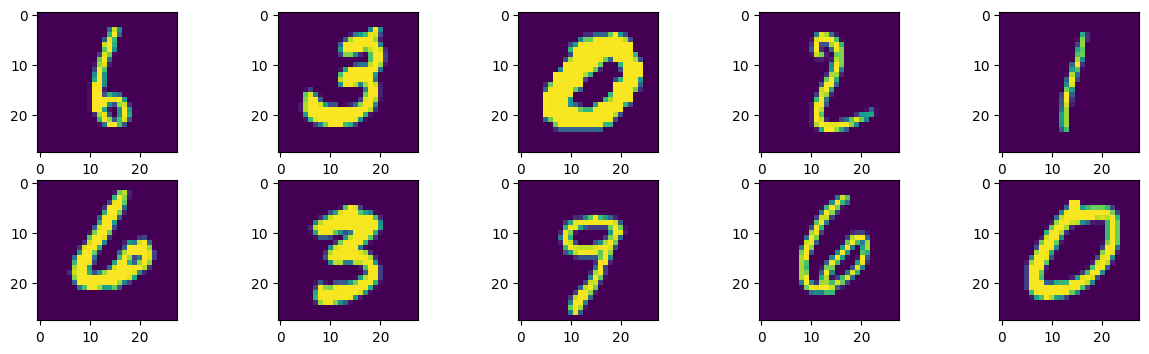

In [47]:

# Ejemplo: Dataset de MNIST
data_bldr= tfds.builder('mnist')
print(data_bldr.info)

# Descarga del dataset y preparación
data_bldr.download_and_prepare()

# Convertir a dataset (train/test)
dataset= data_bldr.as_dataset()
print('Sub-datasets de MNIST: ', dataset.keys())
trainingData= dataset['train']
testData= dataset['test']

# Ordenación aleatoria del dataset de training
trainingData= trainingData.shuffle(buffer_size= len(trainingData))

# Mostrar algunos elementos del dataset
for i, patron in enumerate(trainingData):
    print('Tam. de imagen de entrada: ', patron['image'].shape, 'y salida asociada:', patron['label'])
    if i>=10:
        break

import matplotlib.pyplot as plt

fig= plt.figure(figsize=(15, 4))
for i, patron in enumerate(trainingData):
    if i>=10:
        break
    ax= fig.add_subplot(2, 5, i+1)
    ax.imshow(patron['image'])
plt.show()